# Deus Ex Machina - Project CS4
## (De)Generative AI

### Group components

- Catarina Monteiro
- Diogo Mendes
- Gonçalo Brochado
- Guilherme Vaz
- Matheus Bissacot

## Brief Introduction

The case study presented in the article "Generative AI Bias: A Growing Concern in the Industry" by Bloomberg examines the biases inherent in generative AI models, particularly focusing on Stable Diffusion. It highlights how these models often misrepresent racial and gender demographics in their outputs, perpetuating harmful stereotypes. In this notebook, we will present a step-by-step tutorial about how to avoid these serious issues using an example and applying various methodologies to handle imbalanced data.

## Libraries:

The libraries that were used in these projects are:

- _pandas_ for manipulating datasets | **(Version 2.2.3)**
- _seaborn_ and _matplotlib_ for plot analysis | **(Version 0.13.2)**
- _sklearn_ for preprocessing data, applying algorithms and measuring test results | **(Version 1.5.2)**
- _xgboost_ for applying the XGBoost algorithm | **(Version 2.1.2)**
- _imblearn_ for applying the balance techniques | **(Version 0.12.4)**

The Python version is 3.11.7

In [62]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from imblearn.pipeline import Pipeline, make_pipeline
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, average_precision_score

## Dataset Overview

The [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download) dataset under review consists of credit card transactions made by European cardholders in September 2013, encompassing a total of 284,807 transactions, of which 492 are identified as fraudulent. 

This results in a highly unbalanced dataset, with fraud cases representing only 0.172% of all transactions. The dataset features numerical input variables derived from a Principal Component Analysis (PCA) transformation, with the original features not disclosed due to confidentiality concerns. The variables include 28 principal components (V1 to V28), along with two untransformed features: 'Time,' which indicates the seconds elapsed since the first transaction, and 'Amount,' representing the transaction value. 

The response variable, 'Class,' indicates fraud (1) or non-fraud (0). Given the significant class imbalance, it is recommended to evaluate model performance using the Area Under the Precision-Recall Curve (AUPRC) rather than traditional accuracy metrics, as confusion matrix accuracy may not provide meaningful insights in such scenarios. 

This dataset was collected and analyzed as part of a research collaboration between Worldline and the Machine Learning Group at ULB (Université Libre de Bruxelles) focused on big data mining and fraud detection.

In [2]:
df_credit = pd.read_csv("creditcard.csv")

The first steps are doing the basic analysis: how the dataset is composed, what are the relevant attributes and, in general, try to understand it better. Although simple, it is a crucial step, because after doing this, we understand what changes can be made to improve this dataset.

In [3]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df_credit['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

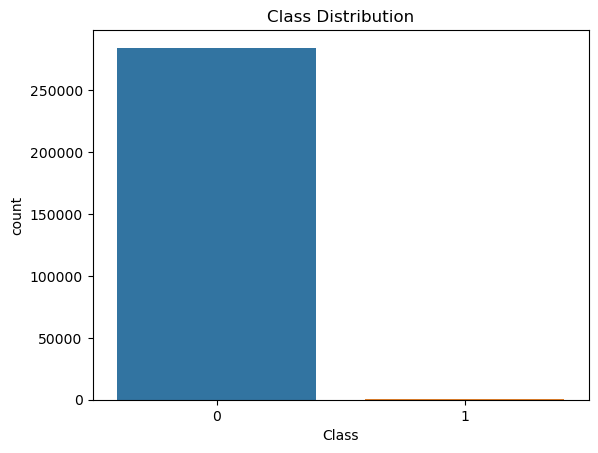

In [6]:
sns.countplot(x='Class', data=df_credit)
plt.title('Class Distribution')
plt.show()

Now let's see the **Time** and **Amount** attributes:

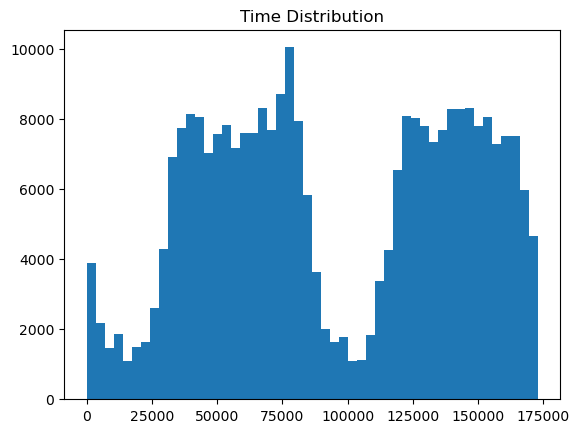

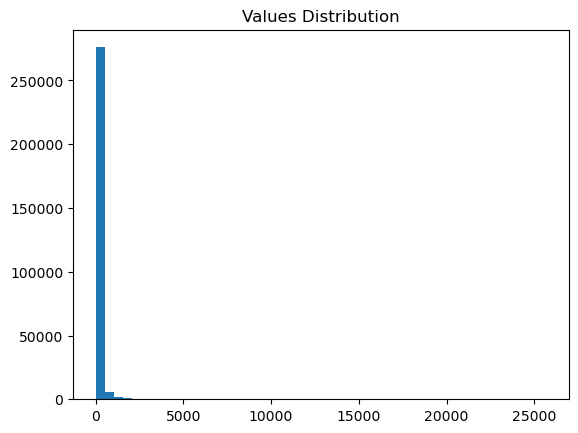

In [7]:
plt.hist(df_credit['Time'], bins=50)
plt.title('Time Distribution')
plt.show()

plt.hist(df_credit['Amount'], bins=50)
plt.title('Values Distribution')
plt.show()


Since there is a clear difference between values in both attributes, we are going to normalize them. (Melhorar essa frase)

In [8]:
df_credit['Amount_Scaled'] = StandardScaler().fit_transform(df_credit['Amount'].values.reshape(-1, 1))
df_credit['Time_Scaled'] = StandardScaler().fit_transform(df_credit['Time'].values.reshape(-1, 1))

# Remove the original columns
df_credit = df_credit.drop(['Time', 'Amount'], axis=1)


In [9]:
df_credit.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_Scaled,Time_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


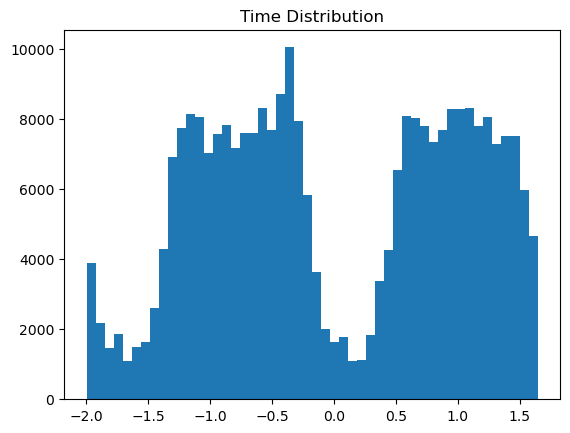

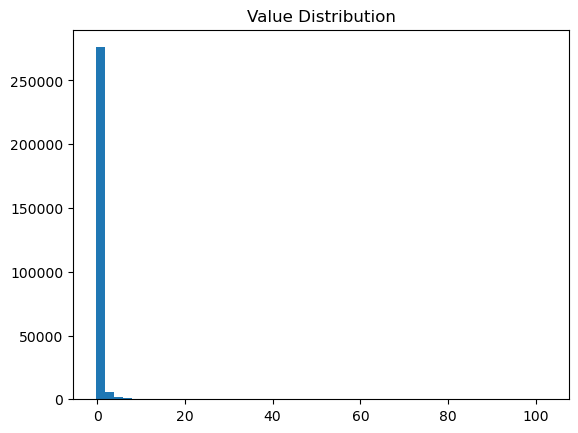

In [10]:
plt.hist(df_credit['Time_Scaled'], bins=50)
plt.title('Time Distribution')
plt.show()

plt.hist(df_credit['Amount_Scaled'], bins=50)
plt.title('Value Distribution')
plt.show()

In [11]:
X = df_credit.drop('Class', axis=1)
y = df_credit['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## Cross-Validation

Cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. The procedure has a single parameter called k that refers to the number of groups that a given data sample is to be split into. As such, the procedure is often called k-fold cross-validation.

The purpose of cross–validation is to test the ability of a machine learning model to predict new data without the risk of overfit, since this approach evaluates the model on multiple validation sets. This way, we guaranteed that cross validation provides a more realistic estimate of the model’s generalization performance.

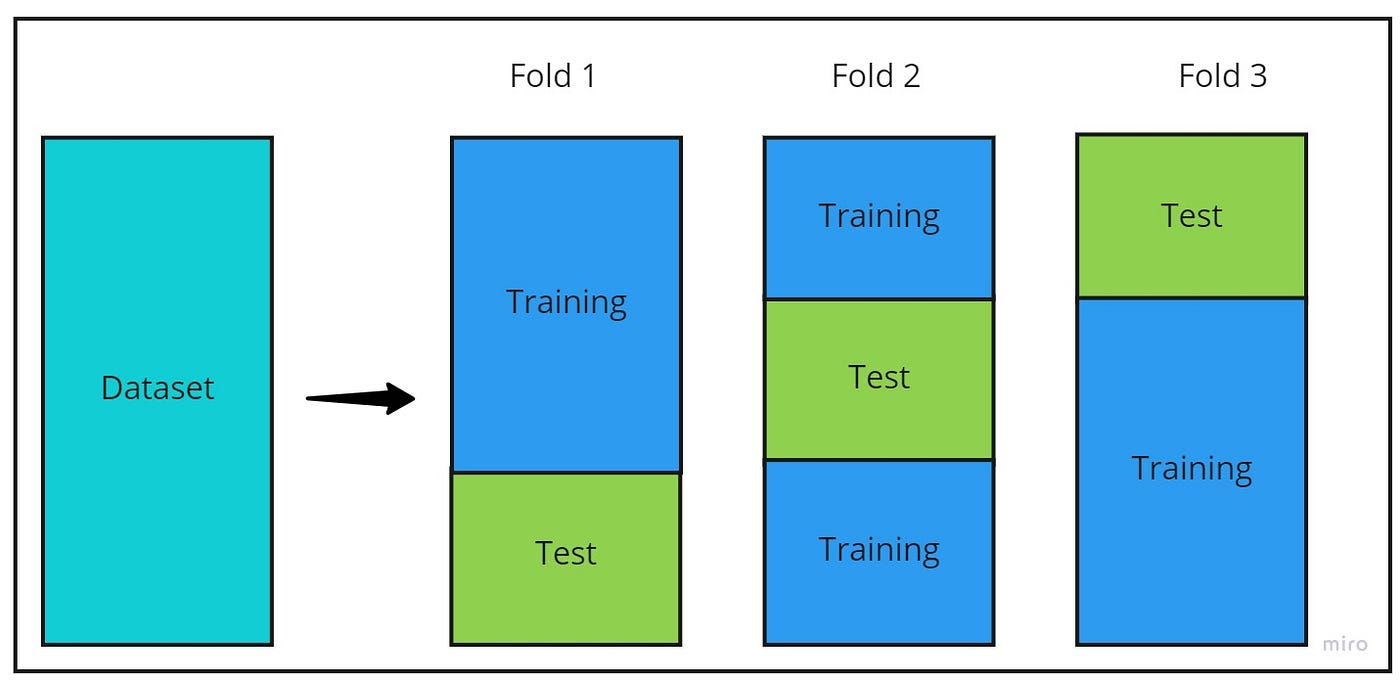

Stratified K-Fold CV (Cross-Validation)
Stratification is used when the datasets contain unbalanced classes. Therefore if we cross-validate with a normal technique it may produce subsamples that have a varying distribution of classes. Some unbalanced samples may produce exceptionally high scores leading to a high cross-validation score overall, which is undesirable. Therefore we create stratified subsamples that preserve the class frequencies in the individual folds to ensure that we are able to get a clear picture of the model performance.

In [12]:
kf = StratifiedKFold(n_splits=5, shuffle=False)

## Random Forest

This is an Ensemble learning method that uses the bagging technique. Basically, it builds multiple decision trees from different subsets of the data, created using bootstrapping (sampling with replacement). Then, each tree makes a prediction, and the final output is determined by the majority voting, i.e the class most predicted by the trees. Finally, it randomly selects a subset of features at each split to reduce correlation between trees.

We chose these algorithm because it is robust to imbalanced data, have adjustable class weights, feature importance and easy-to-implement sampling strategies. Because of these aspects, this algorithm are widely used for researches similar to our case study and get very good results.

In [13]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

score = cross_val_score(model_rf, X_train, y_train, scoring='recall', cv=kf)
print("Cross Validation Recall Scores are: {}".format(score))
print("Average Cross Validation Recall score: {}".format(score.mean()))

Cross Validation Recall Scores are: [0.84057971 0.73913043 0.76811594 0.8115942  0.76470588]
Average Cross Validation Recall score: 0.7848252344416027


In [14]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [15]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85291     4]
 [   36   112]]

          Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   0.965517  0.756757  0.848485  0.999532  0.731083


## XGBoost

Also known as Extreme Gradient Boosting, this is a Gradient boosting framework. It sequentially builds decision trees, where each tree corrects the errors of the previous ones, and, at each step, minimizes a loss function (e.g., log loss for classification) by learning from the residuals. Then, regularization (L1/L2) is applied to control overfitting and, finally, combines the outputs of all trees to make predictions.

Although XGBoost doesn't get the same great results as Random Forest, they are still reliable enough to be picked. But the most important aspect for picking this algorithm definitely is to see how the changes and balance techniques can affect this.

In [16]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

score = cross_val_score(model_xgb, X_train, y_train, scoring='recall', cv=kf)
print("Cross Validation Recall Scores are: {}".format(score))
print("Average Cross Validation Recall score: {}".format(score.mean()))

Cross Validation Recall Scores are: [0.82608696 0.8115942  0.8115942  0.82608696 0.79411765]
Average Cross Validation Recall score: 0.8138959931798807


In [17]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [18]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85279    16]
 [   31   117]]

     Model  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   0.879699  0.790541   0.83274   0.99945  0.695801


## Balancing Techniques

Balancing techniques are methods used to address class imbalance in datasets, ensuring that the minority class is adequately represented during model training. These techniques include oversampling (e.g., SMOTE, ADASYN), undersampling (e.g., Tomek Links, Edited Nearest Neighbors), and hybrid approaches that combine both strategies. The goal of balancing is to improve the model's ability to learn patterns for the minority class, reducing bias and improving classification performance across all classes.

For each balanced dataset, two powerful machine learning algorithms, Random Forest (RF) and XGBoost, will be trained. This methodology ensures a thorough evaluation of how each balancing technique impacts the performance of RF and XGBoost, leveraging their strengths in ensemble learning and gradient boosting, respectively. The results will highlight the effectiveness of the balancing strategies and the predictive capabilities of the models under imbalanced conditions.

### Random Oversampling

Resampling refers to the process of generating a modified version of the training dataset where the examples exhibit a different class distribution. There are two primary methods for random resampling in the context of imbalanced classification: oversampling and undersampling.

These techniques are often called "naive resampling" methods because they do not make any assumptions about the data and do not utilize heuristics. This simplicity allows for easy implementation and quick execution, making them suitable for large and complex datasets.

Random Oversampling involves randomly duplicating instances from the minority class. Because it involves creating exact duplicates of the minority class examples, it can raise the risk of overfitting. For instance, if each data point from the minority class is replicated six times before the dataset is split, then during a 3-fold cross-validation, each fold would, on average, contain two copies of each minority class point. This situation can lead a classifier to develop rules that seem accurate but are actually based on just one of the replicated examples. As a result, the model may perform well on the training data but fail to generalize effectively to unseen data.

In [19]:
over = RandomOverSampler(random_state=42)

In [20]:
X_over, y_over = over.fit_resample(X_train, y_train)

In [21]:
print('0: ' + str(y_over.value_counts()[0]))
print('1: ' + str(y_over.value_counts()[1]))

0: 199020
1: 199020


In [22]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_over, y_over)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [23]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Oversampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85290     5]
 [   40   108]]

          Model            Technique  Precision   Recall  F1 Score  Accuracy  \
0  RandomForest  Random Oversampling   0.955752  0.72973  0.827586  0.999473   

     AUPRCC  
0  0.697909  


In [24]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_over[y_over == 0]) / len(y_over[y_over == 1]))
model_xgb.fit(X_over, y_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [25]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Random Oversampling'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85283    12]
 [   32   116]]

     Model            Technique  Precision    Recall  F1 Score  Accuracy  \
0  XGBoost  Random Oversampling    0.90625  0.783784   0.84058  0.999485   

     AUPRCC  
0  0.710679  


### Random Undersampling

Entails the random selection and removal of examples from the majority class in the training dataset. This method can be particularly effective for datasets with class imbalances, especially when there are enough examples in the minority class to build a reliable model. By reducing the number of majority class instances, random undersampling helps to balance the class distribution, which can enhance the model's ability to learn from the minority class without being overwhelmed by the majority class data.

In [26]:
under = RandomUnderSampler(random_state=42)

In [27]:
X_under, y_under = under.fit_resample(X_train, y_train)

In [28]:
print('0: ' + str(y_under.value_counts()[0]))
print('1: ' + str(y_under.value_counts()[1]))

0: 344
1: 344


In [29]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_under, y_under)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [30]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Random Undersampling'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[83696  1599]
 [   21   127]]

          Model             Technique  Precision    Recall  F1 Score  \
0  RandomForest  Random Undersampling   0.073581  0.858108  0.135539   

   Accuracy    AUPRCC  
0   0.98104  0.063386  


In [31]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_under[y_under == 0]) / len(y_under[y_under == 1]))
model_xgb.fit(X_under, y_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [32]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Random Undersampling'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[82239  3056]
 [   14   134]]

     Model             Technique  Precision    Recall  F1 Score  Accuracy  \
0  XGBoost  Random Undersampling   0.042006  0.905405  0.080288   0.96407   

     AUPRCC  
0  0.038197  


### SMOTE

The Synthetic Minority Oversampling Technique, in short, SMOTE,  method is used to address class imbalance by generating synthetic examples for the minority class. Instead of simply duplicating existing minority class instances, SMOTE creates new samples by selecting existing examples that are close to each other in the feature space.

The process involves the following steps:

1. Selection of Neighbors: For each instance in the minority class, SMOTE identifies its k-nearest neighbors (typically using Euclidean distance).

2. Interpolation: It then randomly selects one or more of these neighbors and creates new synthetic examples along the line segment that connects the original instance to the selected neighbor. This is done by interpolating between the feature values of the two instances.

3. New Sample Generation: The new sample is generated at a point along this line, which introduces variability and helps to create a more diverse set of examples for the minority class.

By synthesizing new instances rather than merely replicating existing ones, SMOTE helps to improve the model's ability to generalize and reduces the risk of overfitting that can occur with simple oversampling techniques.

In [33]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Distribution after SMOTE: {pd.Series(y_train_smote).value_counts()}")

Distribution after SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [34]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [35]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85277    18]
 [   33   115]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest     SMOTE   0.864662  0.777027  0.818505  0.999403  0.672252


In [36]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote[y_train_smote == 0]) / len(y_train_smote[y_train_smote == 1]))
model_xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [37]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85257    38]
 [   29   119]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost     SMOTE   0.757962  0.804054  0.780328  0.999216  0.609782


### B-SMOTE

An enhancement of the original SMOTE, Borderline SMOTE focuses on generating synthetic samples for the minority class near decision boundaries. First it identifies "borderline" samples from the minority class: these are instances close to the majority class or within dense overlapping regions. Then, it generates synthetic samples only for these borderline instances, as they are most at risk of being misclassified.

In [38]:
bsmote = BorderlineSMOTE(random_state=42)
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train)

print(f"Distribution after B-SMOTE: {pd.Series(y_train_smote).value_counts()}")

Distribution after B-SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [39]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_bsmote, y_train_bsmote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [40]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['B-SMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85290     5]
 [   37   111]]

          Model Technique  Precision  Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest   B-SMOTE   0.956897    0.75  0.840909  0.999508  0.718105


In [41]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_bsmote[y_train_bsmote == 0]) / len(y_train_bsmote[y_train_bsmote == 1]))
model_xgb.fit(X_train_bsmote, y_train_bsmote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [42]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['B-SMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85274    21]
 [   31   117]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost   B-SMOTE   0.847826  0.790541  0.818182  0.999391  0.670604


### ADASYN

This is a variant of SMOTE that generates synthetic samples adaptively based on the difficulty of classifying minority class instances. It measures the difficulty of classifying each minority class instance using a metric (e.g., the number of majority class neighbors within a radius), assigns higher weights to more difficult instances and generates more synthetic samples for these areas and creates a balanced dataset while prioritizing regions where the model struggles the most.

In [43]:
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

In [44]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_adasyn, y_train_adasyn)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [45]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['ADASYN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85279    16]
 [   36   112]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest    ADASYN      0.875  0.756757  0.811594  0.999391  0.662583


In [46]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_adasyn[y_train_adasyn == 0]) / len(y_train_adasyn[y_train_adasyn == 1]))
model_xgb.fit(X_train_adasyn, y_train_adasyn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [47]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['ADASYN'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85240    55]
 [   33   115]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost    ADASYN   0.676471  0.777027   0.72327   0.99897  0.526022


### SMOTE-Tomek

Tomek Links is an under-sampling technique developed in 1976 by Ivan Tomek. It is a modification of the Condensed Nearest Neighbors (CNN) algorithm. Tomek Links can be used to identify and remove samples from the majority class that have the lowest Euclidean distance to the minority class data.

Combining over-sampling of the minority (abnormal) class with under-sampling of the majority (normal) class can achieve better classifier performance than only under-sampling the majority class.

First, it begins the SMOTE process by choosing random data from the minority class. Then, it calculates the distance between the random data and its k nearest neighbors. After that, multiply the difference with a random number between 
0 and 1, then add the result to the minority class as a synthetic sample and then repeat the two last steps until the desired proportion of the minority class is met, reaching the end of the SMOTE.

The start of Tomek Links choose random data from the minority class and, if the random data’s nearest neighbor is data from the minority class, then remove the Tomek Link.

By following these steps, the SMOTE-Tomek Links method helps to balance the dataset by both generating synthetic minority class samples and removing majority class samples that are close to the minority class, thus improving the classifier's performance.

This is a hybrid method combining SMOTE for oversampling and Tomek Links for undersampling, aiming to balance the dataset while improving class separation. 

In [48]:
SMOTETomek_pipeline = make_pipeline(SMOTETomek(tomek=TomekLinks(sampling_strategy='majority')), 
                              RandomForestClassifier(n_estimators=50, random_state=42))

In [49]:
SMOTETomek_rf = SMOTETomek_pipeline
SMOTETomek_rf.fit(X_train, y_train)

Pipeline(steps=[('smotetomek',
                 SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'))),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=50, random_state=42))])

In [50]:
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train)

In [51]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smote_tomek, y_train_smote_tomek)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [52]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85277    18]
 [   33   115]]

          Model    Technique  Precision    Recall  F1 Score  Accuracy  \
0  RandomForest  SMOTE-Tomek   0.864662  0.777027  0.818505  0.999403   

     AUPRCC  
0  0.672252  


In [53]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote_tomek[y_train_smote_tomek == 0]) / len(y_train_smote_tomek[y_train_smote_tomek == 1]))
model_xgb.fit(X_train_smote_tomek, y_train_smote_tomek)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [54]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTE-Tomek'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85257    38]
 [   29   119]]

     Model    Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  SMOTE-Tomek   0.757962  0.804054  0.780328  0.999216  0.609782


### SMOTEENN

The SMOTE + Edited Nearest Neighbors is a hybrid technique that combines SMOTE (oversampling) with Edited Nearest Neighbors (ENN, undersampling) to address class imbalance by balancing the dataset and removing noisy samples.

This works by generating synthetic samples for the minority class to reduce imbalance (the SMOTE part) and cleaning the dataset by removing samples whose class label differs from the majority of its nearest neighbors, typically 3-nearest neighbors. This step removes noisy and ambiguous samples from both classes, especially at the decision boundary.

In [55]:
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train, y_train)

In [56]:
model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
model_rf.fit(X_train_smoteenn, y_train_smoteenn)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [57]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['SMOTEENN'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85262    33]
 [   31   117]]

          Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  RandomForest  SMOTEENN       0.78  0.790541  0.785235  0.999251  0.616984


In [58]:
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smoteenn[y_train_smoteenn == 0]) / len(y_train_smoteenn[y_train_smoteenn == 1]))
model_xgb.fit(X_train_smoteenn, y_train_smoteenn)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [59]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['SMOTEENN'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85228    67]
 [   27   121]]

     Model Technique  Precision    Recall  F1 Score  Accuracy    AUPRCC
0  XGBoost  SMOTEENN   0.643617  0.817568  0.720238    0.9989  0.526516


### Hybrid Tomek Links BCBSMOTE (Proposed in Paper)

This approach combines the strengths of Borderline-SMOTE (BC-SMOTE) and Tomek Links to balance datasets and refine decision boundaries. BC-SMOTE focuses on generating synthetic samples for the minority class, specifically for borderline instances near the decision boundary, thereby improving minority class representation in the most challenging regions. Tomek Links identifies and removes pairs of nearest neighbors (one from each class) that are too close, typically considered noise or borderline majority class samples. This process cleans the dataset by improving class separability and removing ambiguity.

In [64]:
# Step 1: Clustering and border identification
minority_class = X_train[y_train == 1]
kmeans = KMeans(n_clusters=5, random_state=42).fit(minority_class)

/home/codebind/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [68]:
# Passo 2: BCBSMOTE - Geração de amostras sintéticas
synthetic_samples = []

for cluster in range(5):
    # Filtrar os dados do cluster
    cluster_data = minority_class[kmeans.labels_ == cluster]
    cluster_data = cluster_data.to_numpy()  # Converter para NumPy para evitar problemas de indexação

    # Encontrar vizinhos mais próximos no cluster
    nbrs = NearestNeighbors(n_neighbors=3).fit(cluster_data)
    distances, indices = nbrs.kneighbors(cluster_data)

    # Criar amostras sintéticas por interpolação
    for i, neighbors in enumerate(indices):
        for neighbor in neighbors:
            if neighbor != i:  # Evitar interpolação com o mesmo ponto
                synthetic_sample = cluster_data[i] + np.random.rand() * (cluster_data[neighbor] - cluster_data[i])
                synthetic_samples.append(synthetic_sample)

synthetic_samples = np.array(synthetic_samples)
X_resampled = np.vstack([X_train, synthetic_samples])
y_resampled = np.hstack([y_train, np.ones(synthetic_samples.shape[0])])

In [69]:
# Step 3: Tomek Links
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek2, y_train_smote_tomek2 = smote_tomek.fit_resample(X_resampled, y_resampled)

In [70]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote_tomek2, y_train_smote_tomek2)

RandomForestClassifier(random_state=42)

In [71]:
y_pred = model_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

rf_Recall = recall_score(y_test, y_pred)
rf_Precision = precision_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, y_pred)
rf_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['RandomForest'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [rf_Precision],
    'Recall': [rf_Recall],
    'F1 Score': [rf_f1],
    'Accuracy': [rf_accuracy],
    'AUPRCC': [rf_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85262    33]
 [   31   117]]

          Model                    Technique  Precision    Recall  F1 Score  \
0  RandomForest  Hybrid Tomek Links BCBSMOTE       0.78  0.790541  0.785235   

   Accuracy    AUPRCC  
0  0.999251  0.616984  


In [72]:
# Passo 4: Treinar o modelo
model_xgb = XGBClassifier(scale_pos_weight=len(y_train_smote_tomek2[y_train_smote_tomek2 == 0]) / len(y_train_smote_tomek2[y_train_smote_tomek2 == 1]))
model_xgb.fit(X_train_smote_tomek2, y_train_smote_tomek2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

xgb_Recall = recall_score(y_test, y_pred)
xgb_Precision = precision_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auprcc = average_precision_score(y_test, y_pred)

print(cm)
print()
data = {
    'Model': ['XGBoost'], 
    'Technique': ['Hybrid Tomek Links BCBSMOTE'],
    'Precision': [xgb_Precision],
    'Recall': [xgb_Recall],
    'F1 Score': [xgb_f1],
    'Accuracy': [xgb_accuracy],
    'AUPRCC': [xgb_auprcc]
}

df = pd.DataFrame(data)
print(df)

[[85271    24]
 [   31   117]]

     Model                    Technique  Precision    Recall  F1 Score  \
0  XGBoost  Hybrid Tomek Links BCBSMOTE   0.829787  0.790541  0.809689   

   Accuracy    AUPRCC  
0  0.999356  0.656343  


: 

## Class Weights

(Fazer aqui essa parte)

## Results

(Fazer comparação todos contra todos
Ex: XGBoost vs Random Forest )

## Conclusion

**https://www.researchgate.net/publication/377619332_Hybrid_Undersampling_and_Oversampling_for_Handling_Imbalanced_Credit_Card_Data**